Kreuztabelle (Anzahl):
treatment   No  Yes
bio_sex            
female      73  166
male       534  442
unknown     15   29

Kreuztabelle (Prozent pro Gender):
treatment         No        Yes
bio_sex                        
female     30.543933  69.456067
male       54.713115  45.286885
unknown    34.090909  65.909091

Chi2-Statistik: 49.14
p-Wert: 0.0000
Freiheitsgrade: 2
Erwartete Häufigkeiten:
[[118.07625099 120.92374901]
 [482.1858618  493.8141382 ]
 [ 21.73788721  22.26211279]]
Cramér's V: 0.198


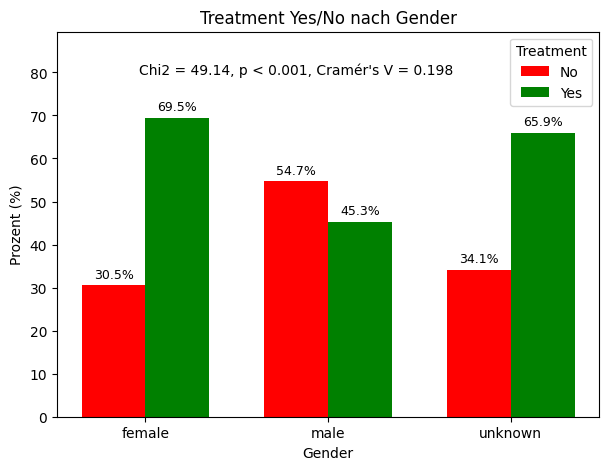

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import numpy as np

# --- Daten einlesen ---
df = pd.read_csv("survey.csv")

# --- Gender bereinigen ---
male_variants = {"male", "m", "mal", "maile"}
female_variants = {"female", "f", "femal", "femail"}

def map_bio_sex_robust(value):
    if pd.isna(value):
        return "unknown"
    v = str(value).strip().lower()
    if v in male_variants:
        return "male"
    if v in female_variants:
        return "female"
    return "unknown"

df["bio_sex"] = df["Gender"].apply(map_bio_sex_robust)

# --- Kreuztabelle Gender vs Treatment ---
ct = pd.crosstab(df["bio_sex"], df["treatment"])
print("Kreuztabelle (Anzahl):")
print(ct)

ct_percent = pd.crosstab(df["bio_sex"], df["treatment"], normalize='index') * 100
print("\nKreuztabelle (Prozent pro Gender):")
print(ct_percent)

# --- Chi-Quadrat-Test ---
chi2, p, dof, expected = chi2_contingency(ct)
print(f"\nChi2-Statistik: {chi2:.2f}")
print(f"p-Wert: {p:.4f}")
print(f"Freiheitsgrade: {dof}")
print("Erwartete Häufigkeiten:")
print(expected)

# --- Effektgröße (Cramér's V) ---
n = ct.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))
print(f"Cramér's V: {cramers_v:.3f}")

# --- Balkendiagramm mit Prozentangaben ---
fig, ax = plt.subplots(figsize=(7,5))

width = 0.35  # Breite der Balken
genders = ct_percent.index.tolist()
treatment_categories = ct_percent.columns.tolist()
x = range(len(genders))

colors = {"Yes": "green", "No": "red"}  # Farbzuordnung

for i, treatment in enumerate(treatment_categories):
    heights = ct_percent[treatment].values
    ax.bar([p + i*width for p in x], heights, width=width, label=treatment, color=colors[treatment])
    # Prozentzahlen über Balken
    for j, h in enumerate(heights):
        ax.text(j + i*width, h + 1, f"{h:.1f}%", ha='center', va='bottom', fontsize=9)

# --- Signifikanzannotation mittig ---
x_mitte = (0 + len(genders) - 1) / 2  # Mittelwert der x-Positionen
y_hoch = ct_percent.values.max() + 10  # Höhe über Balken
ax.text(x_mitte, y_hoch, 
        f"Chi2 = {chi2:.2f}, p < 0.001, Cramér's V = {cramers_v:.3f}", 
        fontsize=10, ha='center')

# Achsen, Titel, Legend
ax.set_xticks([p + width/2 for p in x])
ax.set_xticklabels(genders)
ax.set_ylabel("Prozent (%)")
ax.set_xlabel("Gender")
ax.set_title("Treatment Yes/No nach Gender")
ax.set_ylim(0, ct_percent.values.max() + 20)
ax.legend(title="Treatment")

plt.show()